In [94]:
import pandas as pd
import numpy as np
import glob
from scipy.io import loadmat
import joblib
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from enigmatoolbox.plotting import plot_subcortical
print("ENIGMA Toolbox installed correctly!")


ENIGMA Toolbox installed correctly!


In [95]:
import re

files = np.sort(glob.glob("./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat"))
fc = {}
for f in files:
    tmp = loadmat(f)['subj_final_corr_mat']
    # Extract participant ID using regex
    match = re.search(r"sub-(\d+)_", f)
    if match:
        pid = match.group(1)
        fc[pid] = tmp
    else:
        print(f"Could not extract participant ID from {f}")
print(f"Total files loaded: {len(fc)}")

Total files loaded: 187


# Load demographics

In [96]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import glob
import re

# -----------------------------
# 1) Load FC matrices and mask to demo_merged
# -----------------------------
files = np.sort(glob.glob("./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat"))
fc = {}
for f in files:
    tmp = loadmat(f)['subj_final_corr_mat']
    match = re.search(r"sub-(\d+)_", f)
    if match:
        pid = match.group(1)
        # Only keep subjects present in demo_merged
        if pid in demo_merged['participant_id_num'].values:
            fc[pid] = tmp
    else:
        print(f"Could not extract participant ID from {f}")
print(f"Total FC matrices loaded (masked to demo_merged): {len(fc)}")

# -----------------------------
# 2) Load main demographics CSV
# -----------------------------
demo = pd.read_csv('./BD-SCZ/participants_HC_SCZ_BD.csv', header=1)
demo['participant_id'] = demo['participant_id'].astype(str).str.strip().str.upper()
demo['participant_id_num'] = demo['participant_id'].str.extract(r'(\d+)$')[0]

# Keep only participants with FC
id_df = pd.DataFrame({'participant_id_num': list(fc.keys())})
demo_merged = pd.merge(id_df, demo, on='participant_id_num', how='inner')
print('Merged demo shape:', demo_merged.shape)

# -----------------------------
# 3) Load clinical Excel data and merge
# -----------------------------
clinc_bd = pd.read_excel('./BD-SCZ/Demographics BD.xlsx')
clinc_scz = pd.read_excel('./BD-SCZ/Demographics SCZ.xlsx')

clinic = pd.concat([
    clinc_bd[['participant_id'] + list(clinc_bd.columns[5:])],
    clinc_scz[['participant_id'] + list(clinc_scz.columns[5:])]
], axis=0, ignore_index=True)

clinic['participant_id'] = clinic['participant_id'].astype(str).str.strip().str.upper()
clinic['participant_id_num'] = clinic['participant_id'].str.extract(r'(\d+)$')[0]

demo_merged = pd.merge(demo_merged, clinic, on='participant_id_num', how='left')
print('Final merged demo shape:', demo_merged.shape)
print('Columns:', demo_merged.columns.tolist())

# -----------------------------
# 4) Standardize diagnosis and gender
# -----------------------------
# Use CSV diagnosis as main column
demo_merged['diagnosis'] = demo_merged['diagnosis'].replace({'CONTROL': 1, 'SCHZ': 2, 'BIPOLAR': 3})
# Create diagnosis2 for later grouping (e.g., merge BD into patients if needed)
demo_merged['diagnosis2'] = demo_merged['diagnosis'].copy()
demo_merged.loc[demo_merged['diagnosis2'] == 3, 'diagnosis2'] = 2

# Standardize gender column
if 'gender' in demo_merged.columns:
    demo_merged['gender_num'] = demo_merged['gender'].replace({'M': 1, 'F': 2})
elif 'Gender (1= male; 2=female)' in demo_merged.columns:
    demo_merged['gender_num'] = demo_merged['Gender (1= male; 2=female)'].astype(int)
else:
    raise ValueError("No gender column found!")

print('Diagnosis values:', demo_merged['diagnosis'].unique())
print('Diagnosis2 values:', demo_merged['diagnosis2'].unique())
print('Gender values:', demo_merged['gender_num'].unique())

# -----------------------------
# 5) Extract group FC arrays matching demo order
# -----------------------------
# First 400 parcels
fc_CTR = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1] if i in fc])
fc_SCZ = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2] if i in fc])
fc_BD  = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3] if i in fc])
fc_mix = np.array([fc[i][:400, :400] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1] if i in fc])

print('fc_CTR shape (400 parcels):', fc_CTR.shape)
print('fc_SCZ shape (400 parcels):', fc_SCZ.shape)
print('fc_BD shape  (400 parcels):', fc_BD.shape)
print('fc_mix shape:', fc_mix.shape)

# Full parcel matrices
fc_CTR_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1] if i in fc])
fc_SCZ_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2] if i in fc])
fc_BD_full  = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3] if i in fc])
fc_mix_full = np.array([fc[i] for i in demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1] if i in fc])

print('fc_CTR_full shape (all parcels):', fc_CTR_full.shape)
print('fc_SCZ_full shape (all parcels):', fc_SCZ_full.shape)
print('fc_BD_full shape  (all parcels):', fc_BD_full.shape)
print('fc_mix_full shape:', fc_mix_full.shape)

# Use demo_merged for all downstream analyses
demo = demo_merged.copy()


Total FC matrices loaded (masked to demo_merged): 187
Merged demo shape: (187, 16)
Final merged demo shape: (187, 27)
Columns: ['participant_id_num', 'participant_id_x', 'diagnosis', 'age', 'gender', 'bart', 'bht', 'dwi', 'pamenc', 'pamret', 'rest', 'scap', 'stopsignal', 'T1w', 'taskswitch', 'ScannerSerialNumber', 'participant_id_y', 'DimEx', 'Amotivation', 'global blunted affect', 'global alogia', 'global anhedonia', 'global avolition', 'SAPS Positive Symptoms', 'SAPS disorganization', 'hamilton_21', 'Risperidone equivalent dose']
Diagnosis values: [1 2 3]
Diagnosis2 values: [1 2]
Gender values: [2 1]
fc_CTR shape (400 parcels): (110, 400, 400)
fc_SCZ shape (400 parcels): (37, 400, 400)
fc_BD shape  (400 parcels): (40, 400, 400)
fc_mix shape: (77, 400, 400)
fc_CTR_full shape (all parcels): (110, 419, 419)
fc_SCZ_full shape (all parcels): (37, 419, 419)
fc_BD_full shape  (all parcels): (40, 419, 419)
fc_mix_full shape: (77, 419, 419)


In [97]:
demo

,participant_id_num,participant_id_x,diagnosis,age,gender,bart,bht,dwi,pamenc,pamret,...,global blunted affect,global alogia,global anhedonia,global avolition,SAPS Positive Symptoms,SAPS disorganization,hamilton_21,Risperidone equivalent dose,diagnosis2,gender_num
0,10159,SUB-10159,1,30,F,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2
1,10189,SUB-10189,1,49,M,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,10206,SUB-10206,1,21,M,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
3,10217,SUB-10217,1,33,F,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2
4,10225,SUB-10225,1,35,M,1.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,60079,SUB-60079,3,33,M,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,3.0,3.0,0.0,1.0,27.0,0.00,2,1
183,60080,SUB-60080,3,29,M,1.0,1.0,1.0,1.0,1.0,...,2.0,0.0,4.0,2.0,2.0,3.0,33.0,1.67,2,1
184,60084,SUB-60084,3,32,F,1.0,1.0,1.0,1.0,1.0,...,4.0,1.0,3.0,3.0,1.0,2.0,26.0,15.00,2,2
185,60087,SUB-60087,3,41,M,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,3.0,2.0,0.0,3.0,4.0,0.00,2,1


## Group-average functional connectivity (FC) matrix between 14 subcortical regions and 400 cortical parcels.

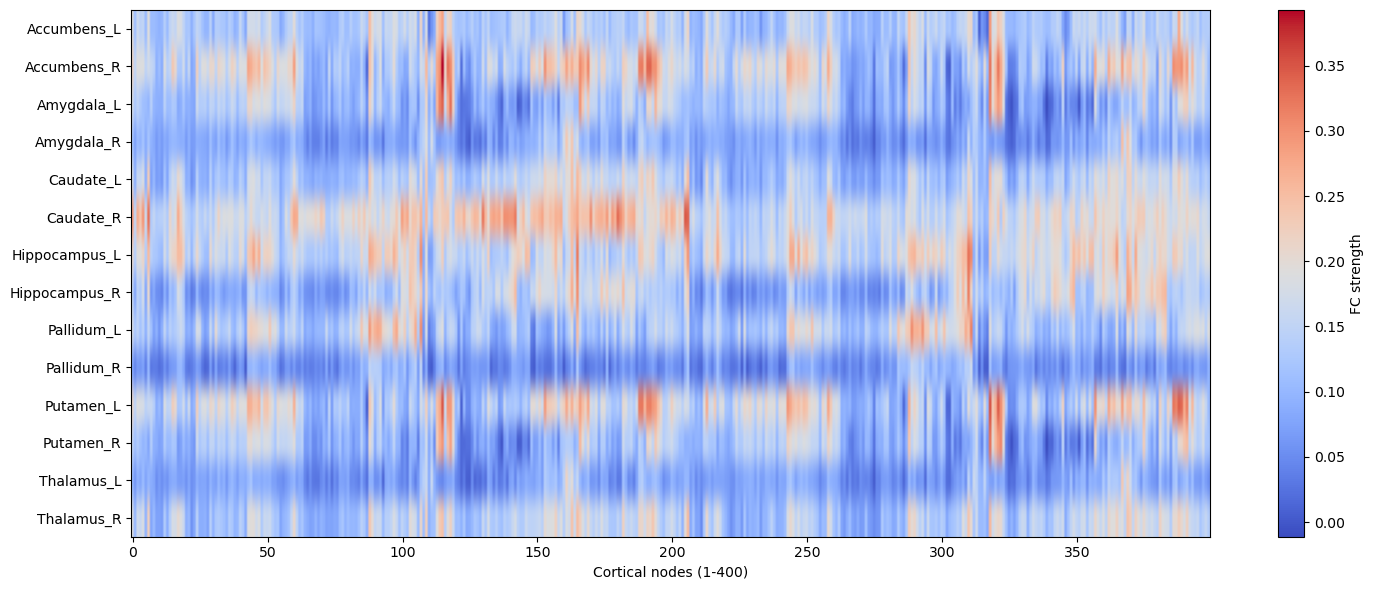

In [98]:
import numpy as np
import matplotlib.pyplot as plt
all_subjects = demo['participant_id_num'].tolist()
fc_full_list = [fc[i] for i in all_subjects if i in fc]
# Compute group-average subcortical-to-cortex FC
# fc_full_list already contains subject FC matrices
subcort_to_cortex = np.array([fc[-14:, :400] for fc in fc_full_list])  # shape: n_subjects x 14 x 400
mean_fc_matrix = subcort_to_cortex.mean(axis=0)  # average across subjects, shape 14 x 400

# Subcortical labels for plotting
subcort_labels = [
    'Accumbens_L', 'Accumbens_R', 'Amygdala_L', 'Amygdala_R',
    'Caudate_L', 'Caudate_R', 'Hippocampus_L', 'Hippocampus_R',
    'Pallidum_L', 'Pallidum_R', 'Putamen_L', 'Putamen_R',
    'Thalamus_L', 'Thalamus_R'
]

# Plot the mean FC matrix
plt.figure(figsize=(15,6))
im = plt.imshow(mean_fc_matrix, aspect='auto', cmap='coolwarm')
plt.yticks(range(len(subcort_labels)), subcort_labels)
plt.xlabel('Cortical nodes (1-400)')
plt.tight_layout()
plt.colorbar(im, label='FC strength')

# Save figure
plt.savefig('./new_figures/subcortical_fc_matrix.png', dpi=300)
plt.show()


# Gradient embedding
“Does this region connect more to the low-gradient cortical areas or the high-gradient areas?”

The Pearson correlation quantifies this.

In [99]:
# --- Step 5: Compute subcortical embeddings for G1, G2, G3 with checks ---

import os

# Gradient files for each gradient
gradient_files = {
    'G1': './g1_aligned_cog_updated.csv',
    'G2': './g2_aligned_cog_updated.csv',
    'G3': './g3_aligned_cog_updated.csv'
}

# Subcortical region names
subcort_regions = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

# Dictionary to store embeddings
subcort_embeddings = {}

# Loop over gradients
for g_name, g_file in gradient_files.items():
    if not os.path.exists(g_file):
        print(f"Gradient file {g_file} not found, skipping {g_name}.")
        continue

    # --- Load gradient CSV ---
    grad_df = pd.read_csv(g_file, index_col=0)

    # --- Extract cortical parcel columns ---
    parcel_cols = [f"node_{i+1}" for i in range(400)]
    g_nodes = grad_df[parcel_cols]

    # --- Compute group-average cortical gradient ---
    gradient_vec = g_nodes.mean(axis=0).to_numpy()
    print(f"{g_name} gradient vector shape: {gradient_vec.shape}")

    # --- Ensure subjects match FC keys ---
    all_subjects_g = demo['participant_id_num'].tolist()
    fc_subjects_g = [s for s in all_subjects_g if s in fc]
    missing_subjects = set(all_subjects_g) - set(fc_subjects_g)
    if missing_subjects:
        print(f"Warning: {len(missing_subjects)} subjects in demo not found in FC for {g_name}: {missing_subjects}")

    # --- Prepare FC list for subjects that exist ---
    fc_full_list_g = [fc[s] for s in fc_subjects_g]

    # --- Compute subcortical embeddings ---
    def compute_embedding(fc_list, gradient_vec):
        results = []
        for subj_fc in fc_list:
            subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)  # positive threshold
            subcort_to_cortex = subj_fc_thr[-14:, :400]
            subj_vals = [pearsonr(subcort_to_cortex[i, :], gradient_vec)[0] for i in range(14)]
            results.append(subj_vals)
        return np.array(results)

    embeddings = compute_embedding(fc_full_list_g, gradient_vec)

    # --- Build DataFrame ---
    subcort_df = pd.DataFrame(embeddings, columns=subcort_regions)
    demo_subcort_g = demo.loc[demo['participant_id_num'].isin(fc_subjects_g)].reset_index(drop=True)
    demo_subcort_g = pd.concat([demo_subcort_g, subcort_df], axis=1)

    # --- Store embeddings and demo DataFrame in dictionary ---
    subcort_embeddings[g_name] = {
        'embeddings': embeddings,
        'demo_subcort': demo_subcort_g
    }

    # --- Save CSV ---
    demo_subcort_g.to_csv(f'./{g_name}_subcortical_embedding_corr_demo.csv', index=False)
    print(f"Saved {g_name} subcortical embedding CSV with demographics!")

# Example access:
# embeddings_g1 = subcort_embeddings['G1']['embeddings']
# demo_subcort_g1 = subcort_embeddings['G1']['demo_subcort']


G1 gradient vector shape: (400,)
Saved G1 subcortical embedding CSV with demographics!
G2 gradient vector shape: (400,)
Saved G2 subcortical embedding CSV with demographics!
G3 gradient vector shape: (400,)
Saved G3 subcortical embedding CSV with demographics!


### Statistical testing
1. Compute subcortical embeddings:
- For each subject, correlate the subcortical-to-cortex connectivity profile of each ROI with the group-average cortical gradient.
- Result: a matrix of size subjects × subcortical ROIs, where each value indicates alignment strength and direction along the gradient.

2. Statistical testing:
- One-sample t-tests are performed for each ROI to test if the mean embedding across subjects is significantly different from zero.
- Positive mean → consistent alignment toward one end of the axis.
- Negative mean → consistent alignment toward the other end.
- FDR correction accounts for multiple comparisons across ROIs.

Significance indicates a consistent gradient alignment across subjects. Mean magnitude and sign indicate the strength and direction of the subcortical-cortical gradient alignment.

In [100]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
import os

# ------------------------------------------
# Subcortical regions (same for all gradients)
# ------------------------------------------
subcort_regions = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

# ------------------------------------------
# One-sample t-test + FDR function
# ------------------------------------------
def run_stats_for_group(embeddings_group, region_names):
    tvals, pvals, means = [], [], []

    for i, roi in enumerate(region_names):
        vals = embeddings_group[:, i]
        t, p = ttest_1samp(vals, 0)
        means.append(vals.mean())
        tvals.append(t)
        pvals.append(p)

    # FDR correction
    reject_fdr, pvals_fdr = fdrcorrection(pvals, alpha=0.05)

    # Interpretation
    interpretation = [
        "Somatomotor-aligned (+)" if m > 0 else
        "Visual-aligned (–)" if m < 0 else
        "No alignment"
        for m in means
    ]

    summary_df = pd.DataFrame({
        "Region": region_names,
        "MeanEmbedding": means,
        "T_value": tvals,
        "P_value": pvals,
        "P_FDR": pvals_fdr,
        "Significant(FDR<0.05)": reject_fdr,
        "Interpretation": interpretation
    })

    # Sort by mean embedding
    summary_df = summary_df.sort_values(by="MeanEmbedding", ascending=False).reset_index(drop=True)
    return summary_df

# ------------------------------------------
# Define groups for masking
# ------------------------------------------
group_masks = {}
for g_name, g_data in subcort_embeddings.items():
    demo_df = g_data['demo_subcort']
    masks = {
        "Whole Sample": np.ones(len(demo_df), dtype=bool),
        "Controls":     (demo_df["diagnosis"] == 1).to_numpy(),
        "BD":           (demo_df["diagnosis"] == 2).to_numpy(),
        "SCZ":          (demo_df["diagnosis"] == 3).to_numpy()
    }
    group_masks[g_name] = masks

# ------------------------------------------
# Run stats for all gradients + groups
# ------------------------------------------
stats_results = {}

for g_name, g_data in subcort_embeddings.items():
    print(f"\nProcessing {g_name} embeddings...\n")
    emb_matrix = g_data['embeddings']
    masks = group_masks[g_name]
    stats_results[g_name] = {}

    for group_name, mask in masks.items():
        emb_group = emb_matrix[mask]
        print(f"{group_name}: N = {emb_group.shape[0]}")
        summary_df = run_stats_for_group(emb_group, subcort_regions)
        stats_results[g_name][group_name] = summary_df

        # Optionally print top results
        print(summary_df)
        print("\n--------------------------------------\n")

    # Save Excel per gradient
    out_file = f"subcortical_embedding_stats_{g_name}.xlsx"
    with pd.ExcelWriter(out_file) as writer:
        for group_name, df in stats_results[g_name].items():
            df.to_excel(writer, sheet_name=group_name[:31], index=False)
    print(f"✓ Saved {g_name} stats to {out_file}")



Processing G1 embeddings...

Whole Sample: N = 187
               Region  MeanEmbedding    T_value       P_value         P_FDR  \
0       sub_Caudate_R       0.095026   5.518062  1.137622e-07  3.185341e-07   
1   sub_Hippocampus_R       0.073562   4.452386  1.461804e-05  3.410876e-05   
2      sub_Amygdala_R       0.037697   2.198642  2.913711e-02  3.708359e-02   
3       sub_Caudate_L       0.031361   1.845795  6.651143e-02  7.759667e-02   
4      sub_Thalamus_R       0.021219   1.237545  2.174449e-01  2.341714e-01   
5      sub_Thalamus_L       0.016169   1.069264  2.863366e-01  2.863366e-01   
6     sub_Accumbens_L      -0.042719  -2.374588  1.858646e-02  2.602104e-02   
7     sub_Accumbens_R      -0.045784  -2.535364  1.205630e-02  1.875425e-02   
8       sub_Putamen_L      -0.050094  -2.906262  4.101998e-03  7.178496e-03   
9   sub_Hippocampus_L      -0.070173  -3.988057  9.566649e-05  1.913330e-04   
10     sub_Pallidum_R      -0.106982  -5.889014  1.784350e-08  6.245224e-08   


## Plotting

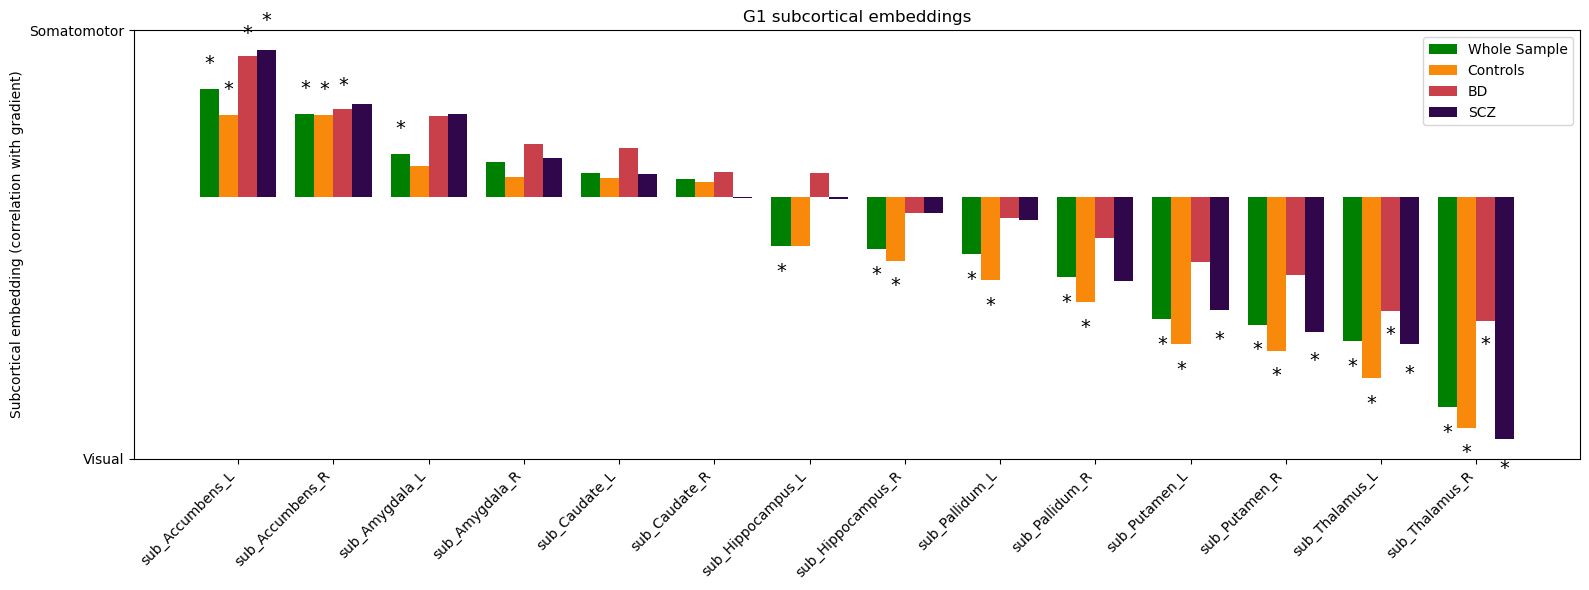

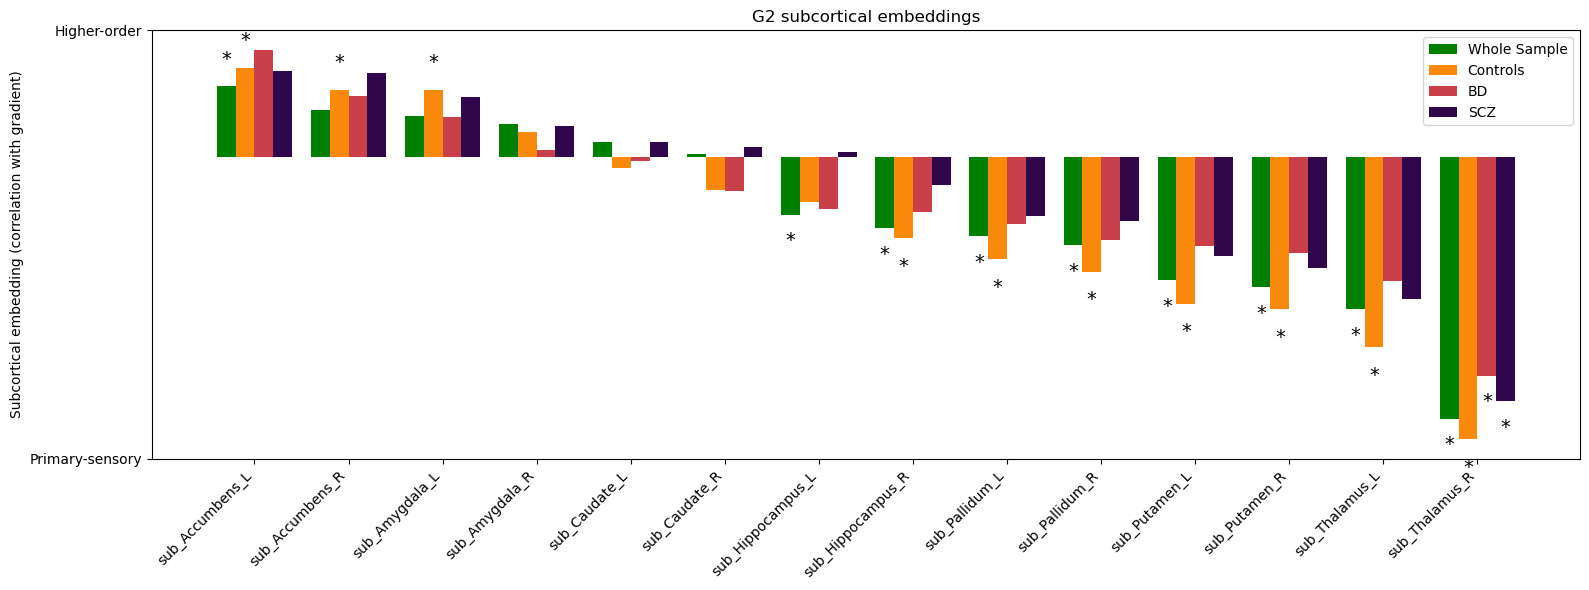

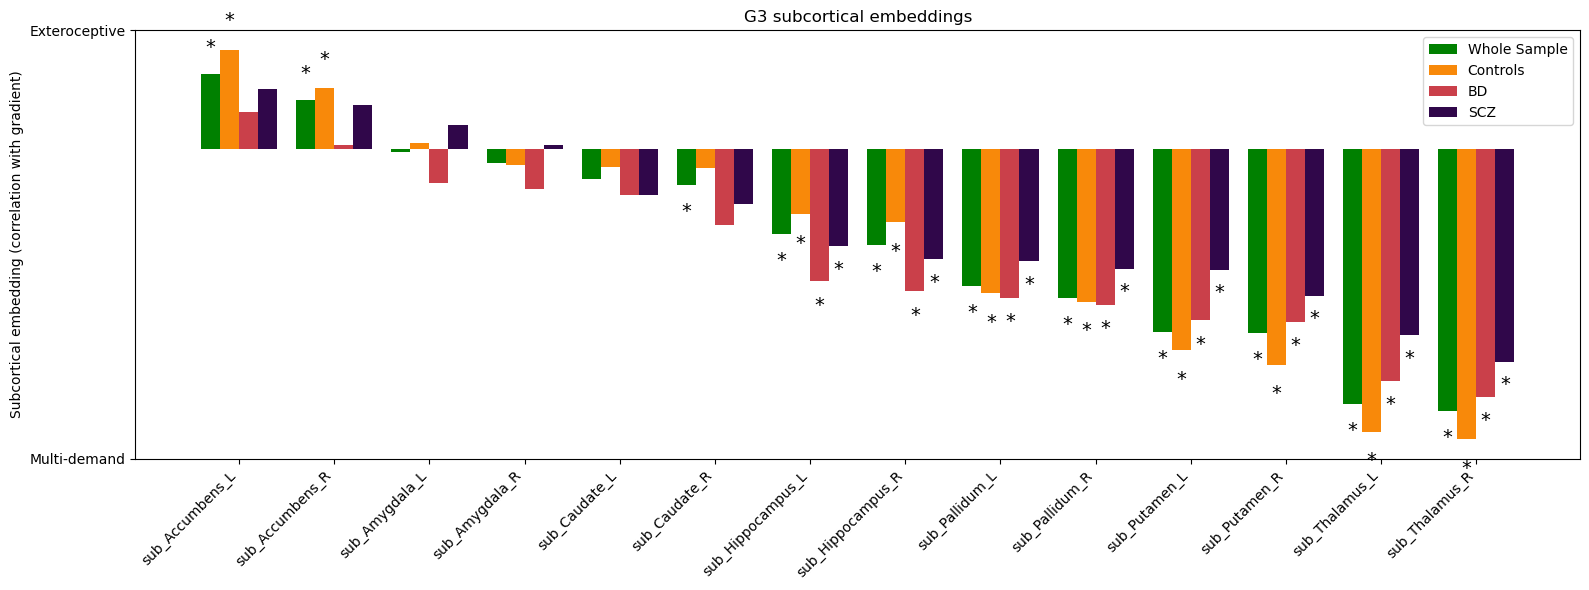

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
# stats_results: dict of dicts -> stats_results[gradient_name][group_name] = summary_df
# subcort_regions: list of 14 region names
# gradient_labels: dict mapping gradient name to y-axis labels
group_colors = {'Whole Sample':'green', 'Controls':'#F8890A', 'BD':'#CA404A', 'SCZ':'#30074A'}
gradient_labels = {
    'G1': ['Visual', 'Somatomotor'],
    'G2': ['Primary-sensory', 'Higher-order'],
    'G3': ['Multi-demand', 'Exteroceptive']  # adjust according to your gradient interpretation
}    
def plot_subcortical_embeddings(stats_results, subcort_regions, gradient_name):
    groups_to_plot = ['Whole Sample', 'Controls', 'BD', 'SCZ']
    n_regions = len(subcort_regions)
    x = np.arange(n_regions)
    width = 0.2  # bar width
    fig, ax = plt.subplots(figsize=(16,6))

    offsets = np.linspace(-width*1.5, width*1.5, len(groups_to_plot))

    for i, group_name in enumerate(groups_to_plot):
        df = stats_results[gradient_name][group_name]
        means = df['MeanEmbedding'].values
        sig_mask = df['Significant(FDR<0.05)'].values

        color = group_colors.get(group_name, 'gray')
        bars = ax.bar(x + offsets[i], means, width, label=group_name, color=color)

        # Stars for significance
        emb_range = max(means) - min(means)
        offset_star = 0.05 * emb_range
        for j, sig in enumerate(sig_mask):
            if sig:
                y_star = means[j] + offset_star if means[j]>=0 else means[j] - offset_star
                va = 'bottom' if means[j]>=0 else 'top'
                ax.text(x[j] + offsets[i], y_star, '*', ha='center', va=va, fontsize=14, color='k')
    
    ax.set_xticks(x)
    ax.set_xticklabels(subcort_regions, rotation=45, ha='right')
    ax.set_ylabel('Subcortical embedding (correlation with gradient)')
    ax.set_title(f'{gradient_name} subcortical embeddings')
    ax.legend()

    # Gradient y-axis labels
    ymin, ymax = ax.get_ylim()
    ax.set_yticks([ymin, ymax])
    ax.set_yticklabels(gradient_labels[gradient_name])

    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot all gradients
# -----------------------------
plot_subcortical_embeddings(stats_results, subcort_regions, 'G1')
plot_subcortical_embeddings(stats_results, subcort_regions, 'G2')
plot_subcortical_embeddings(stats_results, subcort_regions, 'G3')


# Differences between simple correlation (previous) and weighted manifold (following)
| Feature            | Correlation-based Subcortical Embedding                                                 | Weighted Subcortical Manifold                                                                                                   |
| ------------------ | --------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **Measure**        | Pearson correlation between each subcortical ROI’s FC profile and the cortical gradient | Weighted mean of subcortical FC × cortical gradient                                                                             |
| **Input**          | Subcortex-to-cortex FC matrix, cortical gradient                                        | Subcortex-to-cortex FC matrix, cortical gradient                                                                                |
| **Thresholding**   | Optional positive-only (here, positive-only applied)                                    | Always positive-only                                                                                                            |
| **Values / Scale** | r-values between –1 and 1                                                               | Positive real numbers, proportional to FC strength and gradient                                                                 |
| **Interpretation** | Pattern similarity to cortical gradient                                                 | Magnitude of “gradient-aligned connectivity strength”                                                                           |
| **Output shape**   | `(n_subjects × 14)`                                                                     | `(n_subjects × 14)`                                                                                                             |
| **Pros**           | Normalized, comparable across gradients, easy to interpret polarity                     | Captures absolute weighted contribution of cortical gradient; may reflect stronger signal in more connected subcortical regions |
| **Cons**           | Ignores magnitude; can be noisy if FC is weak                                           | Scale depends on FC; not bounded, harder to compare across gradients                                                            |


## Compute subcortical weighted manifold (nodal degree)
This section computes the weighted manifold for each subcortical region using the formula:
$$M_{i} = \frac{1}{N}\sum_{j=1}^{N} C_{i,j} \cdot G_{j}$$
where $C_{i,j}$ is the connectivity between subcortical region $i$ and cortical parcel $j$, $G_{j}$ is the gradient value for cortical parcel $j$, and $N$ is the number of cortical parcels.

In [102]:
import pandas as pd
import numpy as np

# ============================================================
# 1) LOAD ALIGNED GRADIENTS
# ============================================================
g1_aligned = pd.read_csv("g1_aligned_cog_updated.csv", index_col=0)
g2_aligned = pd.read_csv("g2_aligned_cog_updated.csv", index_col=0)
g3_aligned = pd.read_csv("g3_aligned_cog_updated.csv", index_col=0)

# ------------------------------------------------------------
# Keep only cortical parcel columns (1–400)
# ------------------------------------------------------------
parcel_cols = [f"node_{i+1}" for i in range(400)]

g1_nodes = g1_aligned[parcel_cols]
g2_nodes = g2_aligned[parcel_cols]
g3_nodes = g3_aligned[parcel_cols]

# ------------------------------------------------------------
# Compute GROUP-AVERAGE cortical gradient (vector length = 400)
# ------------------------------------------------------------
gradient_vec_g1 = g1_nodes.mean(axis=0).to_numpy()
gradient_vec_g2 = g2_nodes.mean(axis=0).to_numpy()
gradient_vec_g3 = g3_nodes.mean(axis=0).to_numpy()

print("G1 gradient:", gradient_vec_g1.shape)
print("G2 gradient:", gradient_vec_g2.shape)
print("G3 gradient:", gradient_vec_g3.shape)

# Store gradients in dictionary
gradients = {
    "G1": gradient_vec_g1,
    "G2": gradient_vec_g2,
    "G3": gradient_vec_g3
}



# ============================================================
# 2) KEEP **ONLY THE 187 SUBJECTS THAT HAVE FC**
# ============================================================

# 187-subject list used also for embeddings
fc_subjects_187 = subcort_embeddings["G1"]["demo_subcort"]["participant_id_num"].tolist()
print("Number of FC subjects:", len(fc_subjects_187))  # should be 187


# ------------------------------------------------------------
# Build FC array aligned to those 187 subjects
# ------------------------------------------------------------
# fc is assumed to be a dict: fc[subject_id] -> (419x419) FC matrix
fc_all_187 = np.array([fc[pid] for pid in fc_subjects_187])
print("fc_all_187 shape:", fc_all_187.shape)  # (187, 419, 419)


# ------------------------------------------------------------
# Align demographic table to the SAME ordering
# ------------------------------------------------------------
demo_187 = demo.loc[demo["participant_id_num"].isin(fc_subjects_187)]
demo_187 = demo_187.set_index("participant_id_num").loc[fc_subjects_187].reset_index()

print("demo_187 shape:", demo_187.shape)



# ============================================================
# 3) GROUP MASKS (now 187 subjects)
# ============================================================
groups_187 = {
    "Whole Sample": np.ones(len(fc_subjects_187), dtype=bool),
    "Controls":     np.array(demo_187["diagnosis"] == 1),
    "BD":           np.array(demo_187["diagnosis"] == 3),
    "SCZ":          np.array(demo_187["diagnosis"] == 2)
}



# ============================================================
# 4) SUBCORTICAL MANIFOLD COMPUTATION (corrected)
# ============================================================
def compute_subcortical_weighted_manifold(fc_group_full, gradient_vec):
    """
    Compute subcortical weighted manifold index.
    Thresholds FC to keep only positive values.
    """
    results = []

    for subj_fc in fc_group_full:
        # Keep only positive weights
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)

        # Extract subcortex-to-cortex FC
        Ci_j = subj_fc_thr[-14:, :400]   # (14 subcort, 400 cortex)

        # Weighted embedding
        Mi = (Ci_j * gradient_vec[np.newaxis, :]).mean(axis=1)

        results.append(Mi)

    return np.array(results)



# ============================================================
# 5) COMPUTE WEIGHTED MANIFOLDS FOR ONLY THE 187 SUBJECTS
# ============================================================
Mi_all = {}

for g_name, g_vec in gradients.items():
    Mi_all[g_name] = compute_subcortical_weighted_manifold(fc_all_187, g_vec)
    print(f"{g_name} weighted manifold shape:", Mi_all[g_name].shape)


G1 gradient: (400,)
G2 gradient: (400,)
G3 gradient: (400,)
Number of FC subjects: 187
fc_all_187 shape: (187, 419, 419)
demo_187 shape: (187, 29)
G1 weighted manifold shape: (187, 14)
G2 weighted manifold shape: (187, 14)
G3 weighted manifold shape: (187, 14)


In [103]:
import numpy as np

# --- Function: compute subcortical weighted manifold ---
def compute_subcortical_weighted_manifold(fc_group, gradient_vec):
    """
    Compute subcortical weighted manifold index for a group of subjects.
    
    fc_group: n_subjects x n_parcels x n_parcels FC matrices (numpy array)
    gradient_vec: cortical gradient vector (length 400)
    
    Returns: n_subjects x 14 subcortical weighted manifold
    """
    results = []
    for subj_fc in fc_group:
        # Keep only positive correlations
        subj_fc_thr = np.where(subj_fc > 0, subj_fc, 0)
        # Subcortex-to-cortex connectivity (last 14 rows = subcortical)
        Ci_j = subj_fc_thr[-14:, :400]
        # Weighted mean embedding per subcortical region
        Mi = (Ci_j * gradient_vec[np.newaxis, :]).mean(axis=1)
        results.append(Mi)
    return np.array(results)

# --- List of gradients ---
gradients = {
    'G1': gradient_vec_g1,
    'G2': gradient_vec_g2,
    'G3': gradient_vec_g3
}

# --- Subject IDs aligned to fc_all ---
all_subject_ids = (
    list(demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1]) +
    list(demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2]) +
    list(demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3]) +
    list(demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1])
)

groups = {
    "Whole Sample": np.ones(len(all_subject_ids), dtype=bool),
    "Controls":     np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 1 for pid in all_subject_ids]),
    "BD":           np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 3 for pid in all_subject_ids]),
    "SCZ":          np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 2 for pid in all_subject_ids])
}

# --- Compute weighted manifolds per gradient and per group ---
Mi_all = {}

# Concatenate all subjects' FC matrices
fc_all = np.concatenate([fc_CTR_full, fc_SCZ_full, fc_BD_full, fc_mix_full], axis=0)
print("fc_all shape:", fc_all.shape)  # (n_total_subjects, n_parcels, n_parcels)

for g_name, g_vec in gradients.items():
    Mi_all[g_name] = {}
    for group_name, mask in groups.items():
        fc_group = fc_all[mask]  # apply mask during computation
        Mi_all[g_name][group_name] = compute_subcortical_weighted_manifold(fc_group, g_vec)
        print(f"{g_name} - {group_name} weighted manifold shape: {Mi_all[g_name][group_name].shape}")


fc_all shape: (264, 419, 419)
G1 - Whole Sample weighted manifold shape: (264, 14)
G1 - Controls weighted manifold shape: (110, 14)
G1 - BD weighted manifold shape: (80, 14)
G1 - SCZ weighted manifold shape: (74, 14)
G2 - Whole Sample weighted manifold shape: (264, 14)
G2 - Controls weighted manifold shape: (110, 14)
G2 - BD weighted manifold shape: (80, 14)
G2 - SCZ weighted manifold shape: (74, 14)
G3 - Whole Sample weighted manifold shape: (264, 14)
G3 - Controls weighted manifold shape: (110, 14)
G3 - BD weighted manifold shape: (80, 14)
G3 - SCZ weighted manifold shape: (74, 14)


## Statistical testing

In [104]:
# 2) Statistical testing for Mi_all using demo_merged
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

subcort_regions = [
    'sub_Accumbens_L', 'sub_Accumbens_R', 'sub_Amygdala_L', 'sub_Amygdala_R',
    'sub_Caudate_L', 'sub_Caudate_R', 'sub_Hippocampus_L', 'sub_Hippocampus_R',
    'sub_Pallidum_L', 'sub_Pallidum_R', 'sub_Putamen_L', 'sub_Putamen_R',
    'sub_Thalamus_L', 'sub_Thalamus_R'
]

def run_stats_for_group(matrix, region_names):
    tvals, pvals, means = [], [], []
    for i in range(len(region_names)):
        vals = matrix[:, i]
        t, p = ttest_1samp(vals, 0, nan_policy='omit')
        means.append(np.nanmean(vals))
        pvals.append(1.0 if np.isnan(p) else p)
        tvals.append(t)

    reject_fdr, pvals_fdr = fdrcorrection(pvals, alpha=0.05)
    interpretation = [
        "Somatomotor-aligned (+)" if m > 0 else
        "Visual-aligned (–)" if m < 0 else
        "No alignment"
        for m in means
    ]

    return pd.DataFrame({
        "Region": region_names,
        "MeanMi": means,
        "T_value": tvals,
        "P_value": pvals,
        "P_FDR": pvals_fdr,
        "Significant(FDR<0.05)": reject_fdr,
        "Interpretation": interpretation
    }).sort_values("MeanMi", ascending=False).reset_index(drop=True)

# Build fc_all and the matching subject ID list
fc_all = []
fc_all_ids = []

# Controls
for pid in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 1]:
    if pid in fc:
        fc_all.append(fc[pid])
        fc_all_ids.append(pid)

# SCZ
for pid in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 2]:
    if pid in fc:
        fc_all.append(fc[pid])
        fc_all_ids.append(pid)

# BD
for pid in demo_merged['participant_id_num'][demo_merged['diagnosis'] == 3]:
    if pid in fc:
        fc_all.append(fc[pid])
        fc_all_ids.append(pid)

# Mix (all patients)
for pid in demo_merged['participant_id_num'][demo_merged['diagnosis'] != 1]:
    if pid in fc:
        fc_all.append(fc[pid])
        fc_all_ids.append(pid)

fc_all = np.array(fc_all)
print("fc_all shape:", fc_all.shape)
print("Number of IDs:", len(fc_all_ids))

# ---- Correct masks aligned to fc_all / Mi_all ----
all_subject_ids = fc_all_ids

groups = {
    "Whole Sample": np.ones(len(all_subject_ids), dtype=bool),
    "Controls":     np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 1 for pid in all_subject_ids]),
    "BD":           np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 3 for pid in all_subject_ids]),
    "SCZ":          np.array([demo_merged.loc[demo_merged['participant_id_num'] == pid, "diagnosis"].values[0] == 2 for pid in all_subject_ids])
}


# ---- FIXED LOOP ----
stats_results_mi = {}

for g_name in Mi_all.keys():
    print(f"\nProcessing {g_name} (Mi) ...")
    stats_results_mi[g_name] = {}

    for group_name in groups.keys():

        matrix = Mi_all[g_name][group_name]   # <-- direct matrix access
        
        print(f"  {group_name}: N = {matrix.shape[0]}")

        stats_df = run_stats_for_group(matrix, subcort_regions)
        stats_results_mi[g_name][group_name] = stats_df

    # Save to Excel
    out_file = f"subcortical_weighted_manifold_stats_{g_name}.xlsx"
    with pd.ExcelWriter(out_file) as writer:
        for group_name, df in stats_results_mi[g_name].items():
            df.to_excel(writer, sheet_name=group_name[:31], index=False)

    print(f"Saved stats to {out_file}")


fc_all shape: (264, 419, 419)
Number of IDs: 264

Processing G1 (Mi) ...
  Whole Sample: N = 264
  Controls: N = 110
  BD: N = 80
  SCZ: N = 74
Saved stats to subcortical_weighted_manifold_stats_G1.xlsx

Processing G2 (Mi) ...
  Whole Sample: N = 264
  Controls: N = 110
  BD: N = 80
  SCZ: N = 74
Saved stats to subcortical_weighted_manifold_stats_G2.xlsx

Processing G3 (Mi) ...
  Whole Sample: N = 264
  Controls: N = 110
  BD: N = 80
  SCZ: N = 74
Saved stats to subcortical_weighted_manifold_stats_G3.xlsx


## Plotting

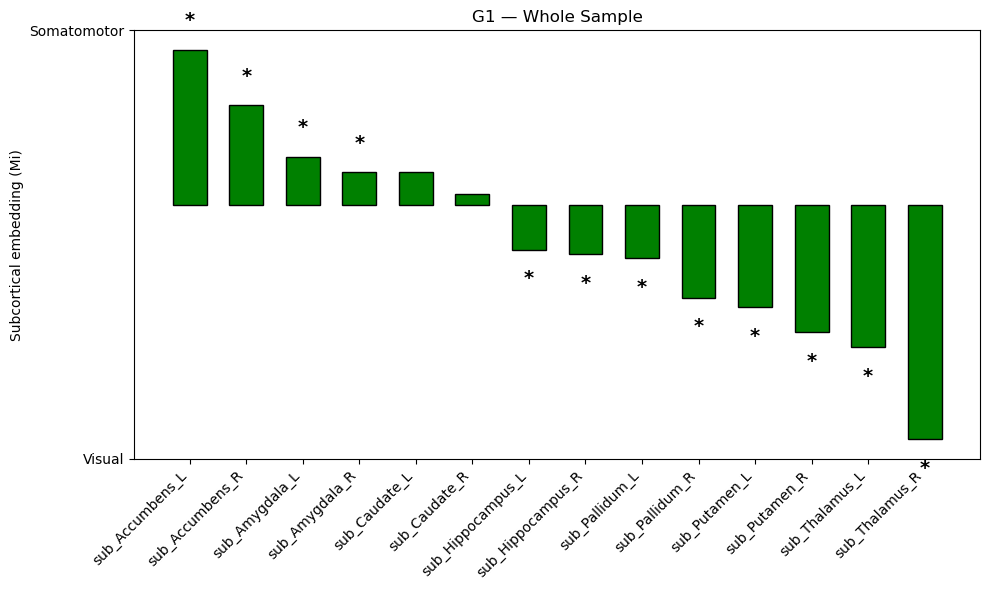

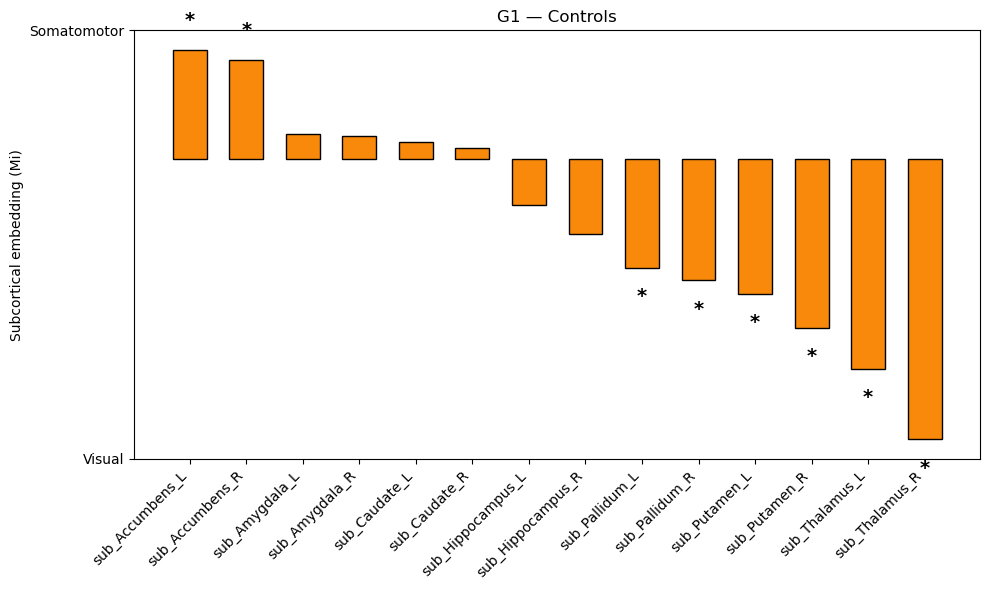

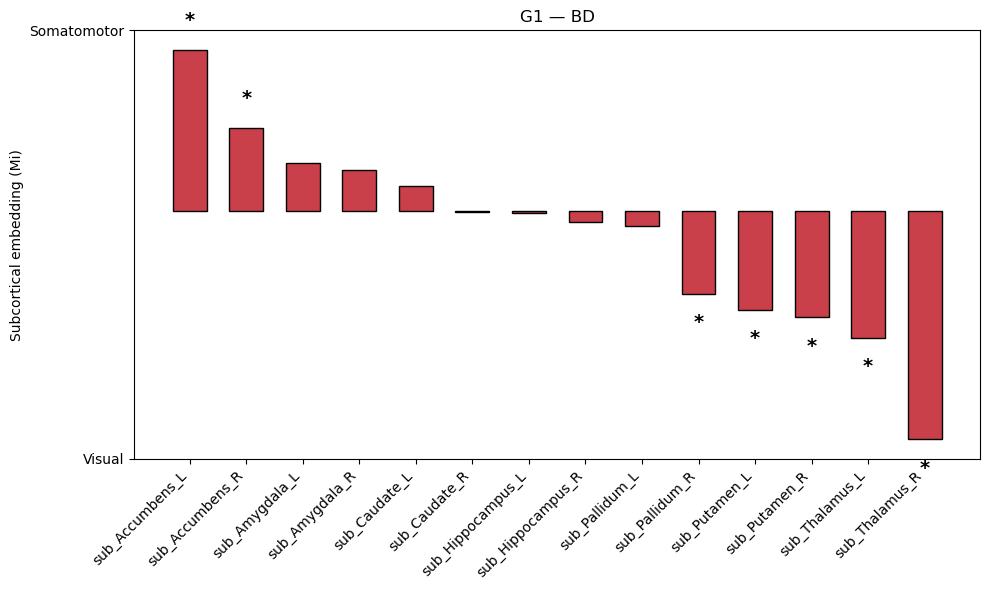

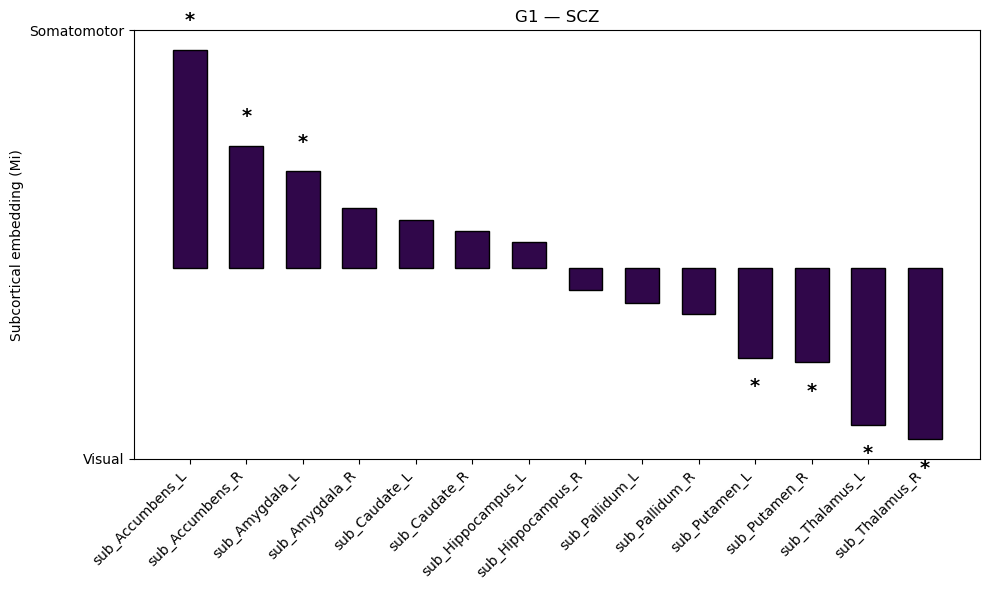

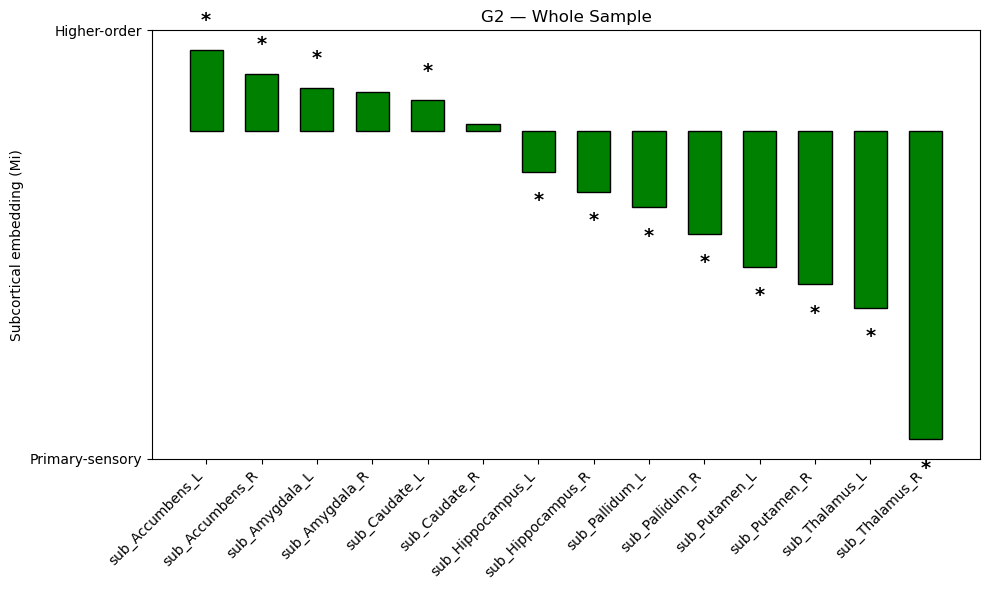

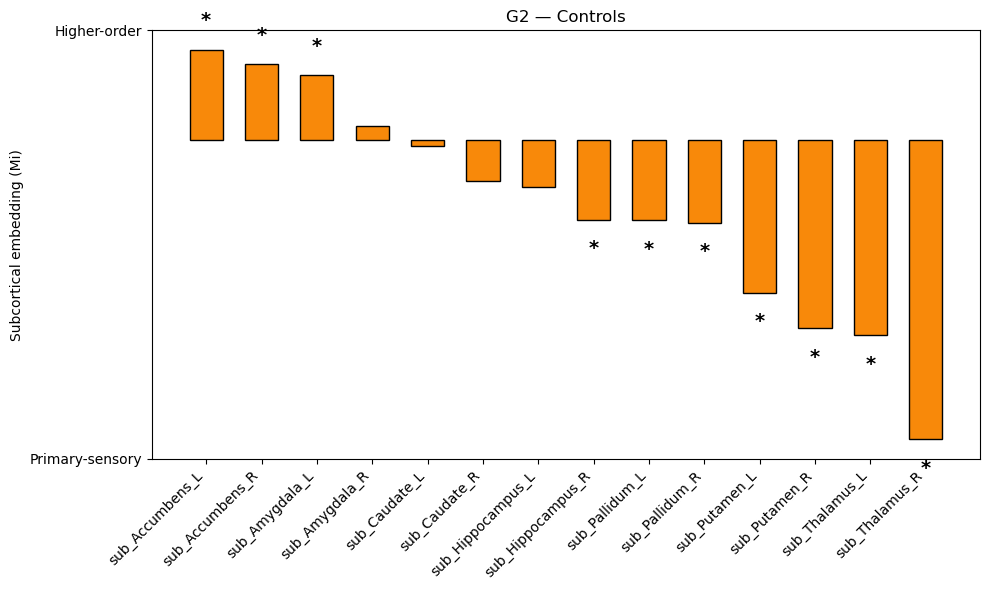

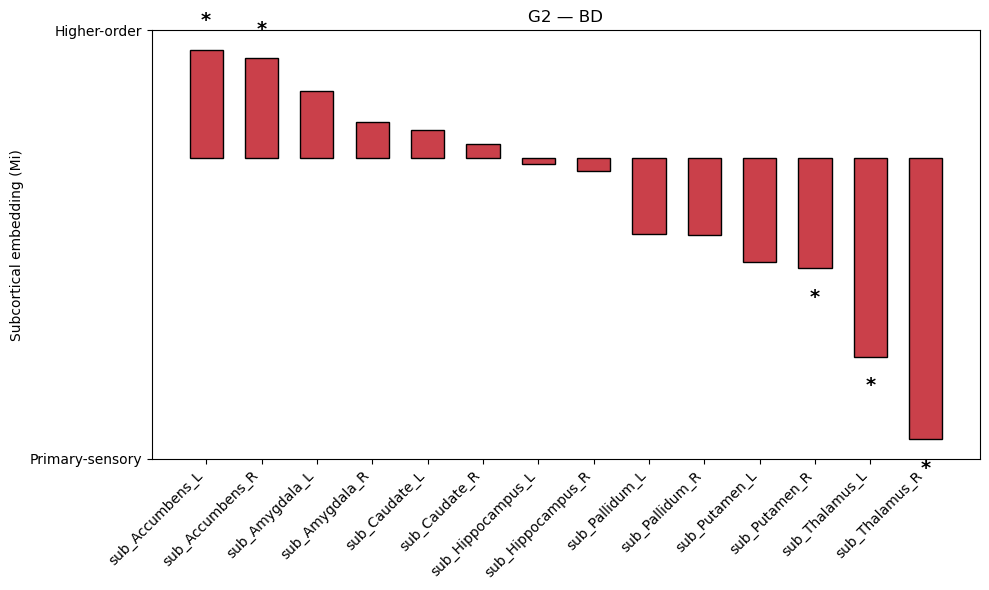

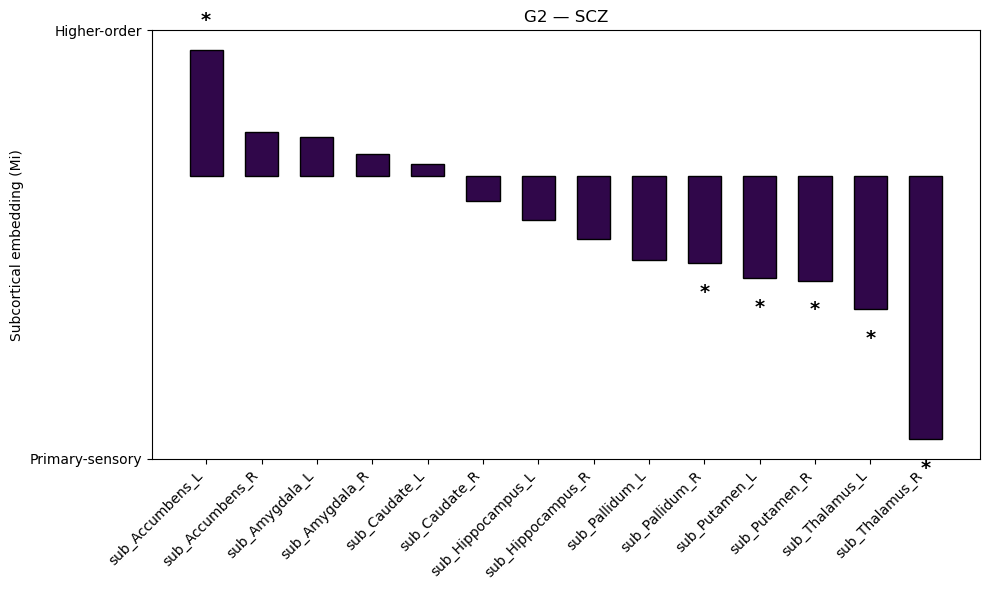

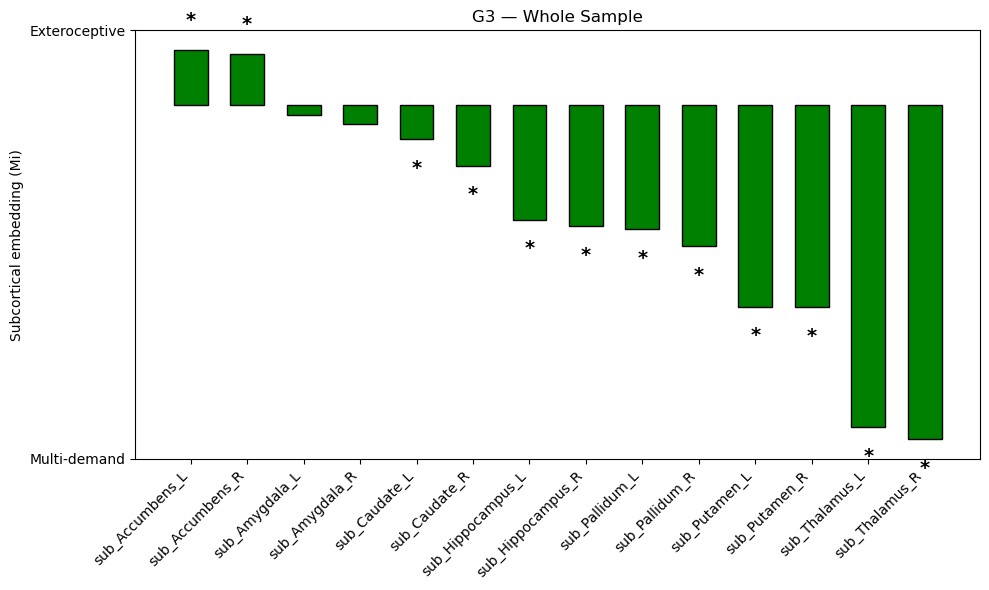

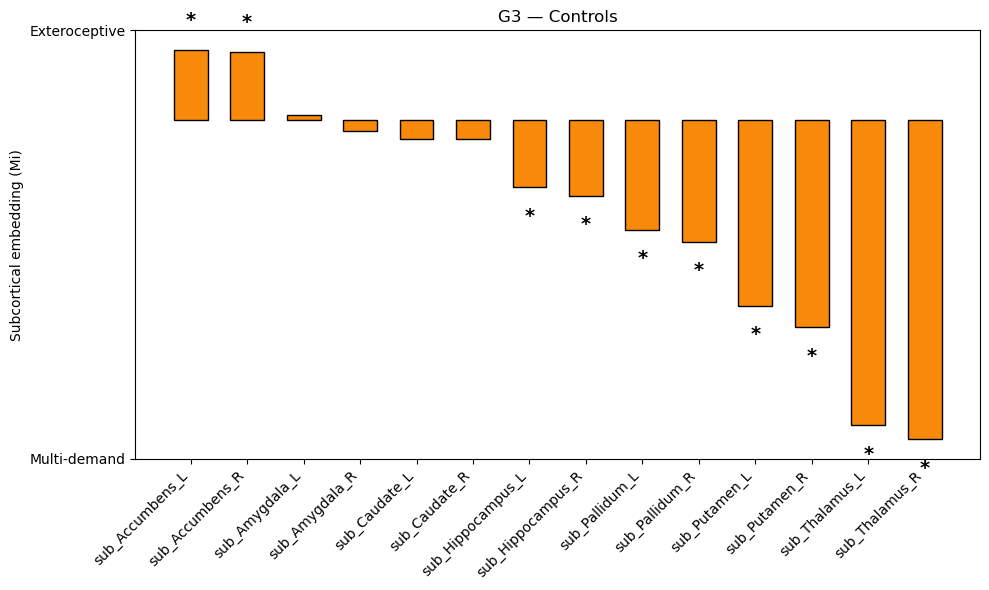

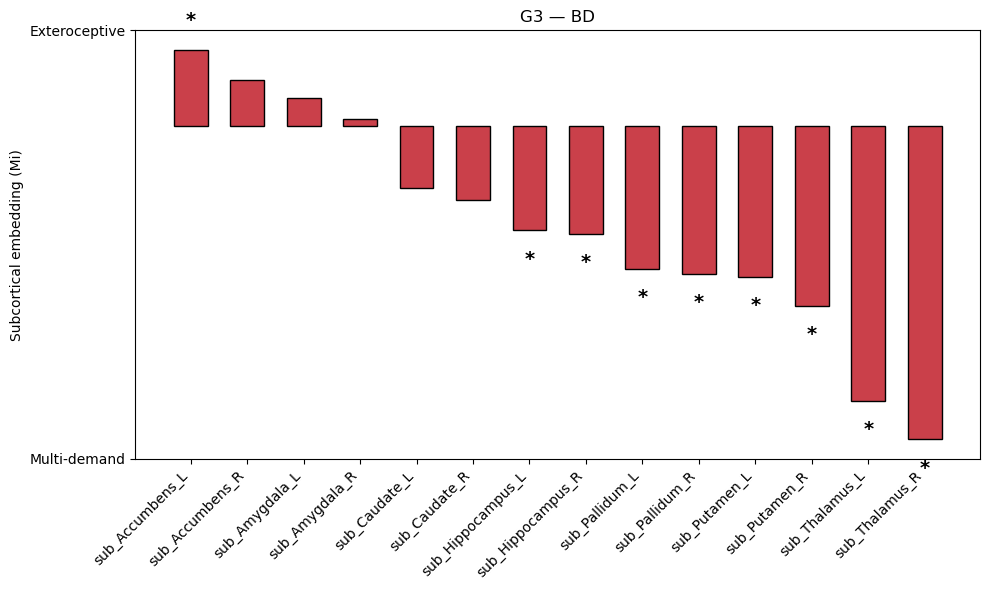

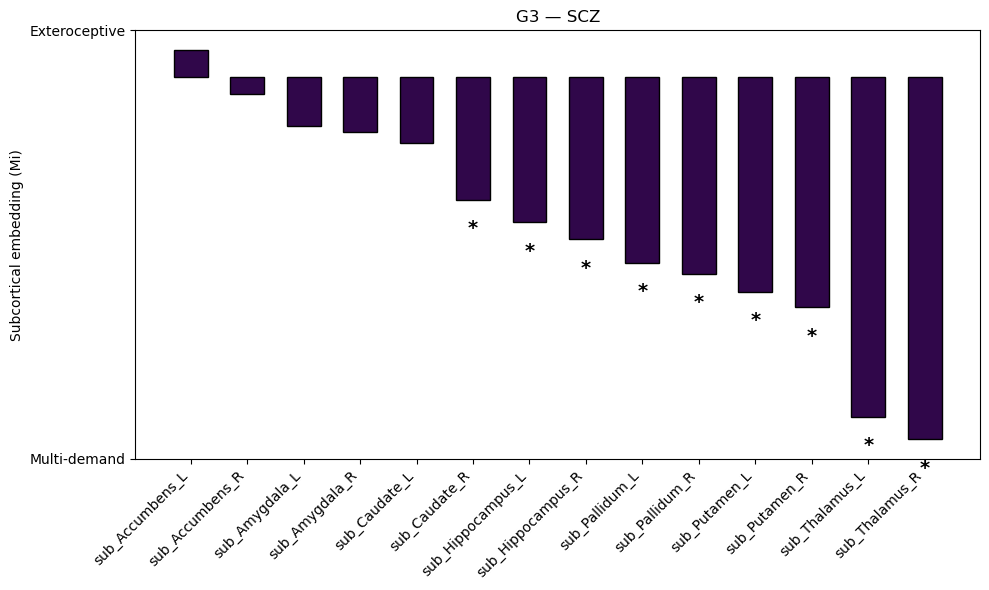

In [105]:
import numpy as np
import matplotlib.pyplot as plt

group_colors = {'Whole Sample':'green', 'Controls':'#F8890A', 'BD':'#CA404A', 'SCZ':'#30074A'}
gradient_labels = {
    'G1': ['Visual', 'Somatomotor'],
    'G2': ['Primary-sensory', 'Higher-order'],
    'G3': ['Multi-demand', 'Exteroceptive']
}

def plot_subcortical_embeddings(stats_results, subcort_regions, gradient_name):
    groups_to_plot = ['Whole Sample', 'Controls', 'BD', 'SCZ']
    n_regions = len(subcort_regions)
    x = np.arange(n_regions)
    width = 0.6  # full width of each bar (single group plot)
    
    for group_name in groups_to_plot:
        df = stats_results[gradient_name][group_name]
        means = df['MeanMi'].values
        sig_mask = df['Significant(FDR<0.05)'].values

        fig, ax = plt.subplots(figsize=(10,6))
        bars = ax.bar(x, means, width, color=group_colors[group_name], edgecolor='k')

        # Add stars for significant regions
        for i, sig in enumerate(sig_mask):
            if sig:
                offset_star = 0.05 * (max(means)-min(means))
                y_star = means[i] + offset_star if means[i] >=0 else means[i] - offset_star
                va = 'bottom' if means[i]>=0 else 'top'
                ax.text(x[i], y_star, '*', ha='center', va=va, fontsize=14, fontweight='bold', color='k')

        # X-axis labels
        ax.set_xticks(x)
        ax.set_xticklabels(subcort_regions, rotation=45, ha='right')

        # Y-axis label and gradient interpretation
        ax.set_ylabel('Subcortical embedding (Mi)')
        ax.set_title(f'{gradient_name} — {group_name}')
        ymin, ymax = ax.get_ylim()
        ax.set_yticks([ymin, ymax])
        ax.set_yticklabels(gradient_labels[gradient_name])

        plt.tight_layout()
        plt.show()

# Plot
plot_subcortical_embeddings(stats_results_mi, subcort_regions, 'G1')
plot_subcortical_embeddings(stats_results_mi, subcort_regions, 'G2')
plot_subcortical_embeddings(stats_results_mi, subcort_regions, 'G3')


# Group comparison

In [106]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
from statsmodels.stats.multitest import fdrcorrection
from sklearn.linear_model import LinearRegression

# -----------------------------
# Helper functions
# -----------------------------
def ensure_numeric_encoding(df, col):
    """Ensure categorical columns (e.g., gender) are numeric."""
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def test_normality(x):
    """Return True if normal (p > 0.05)"""
    return normaltest(x).pvalue > 0.05

def regress_out(X, covariates):
    """
    Regress out confounding variables (e.g., age, gender) from each column of X.
    X: n × p data matrix
    covariates: n × k matrix of confound variables
    """
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

def pairwise_tests(features, labels, region_names, group_pairs):
    """
    Perform pairwise comparisons for specified group pairs.
    Only include columns for the groups being compared.
    """
    all_rows = []
    for g1, g2 in group_pairs:
        rows, pvals = [], []
        for i, roi in enumerate(region_names):
            x1 = features[labels == g1, i]
            x2 = features[labels == g2, i]

            if len(x1) == 0 or len(x2) == 0:
                continue

            is_normal = test_normality(x1) and test_normality(x2)
            stat, p = (ttest_ind(x1, x2, nan_policy='omit') 
                       if is_normal else mannwhitneyu(x1, x2))

            rows.append({
                'Region': roi,
                'Comparison': f'{g1}_vs_{g2}',
                f'{g1}_mean': x1.mean(),
                f'{g2}_mean': x2.mean(),
                'stat': stat,
                'p': p
            })
            pvals.append(p)

        # Apply FDR correction
        if rows:
            _, p_fdr = fdrcorrection(pvals)
            for r, pf in zip(rows, p_fdr):
                r['p_FDR'] = pf
            all_rows.extend(rows)

    return pd.DataFrame(all_rows)

# -----------------------------
# Build aligned datasets
# -----------------------------
# Subcortical embeddings
embeddings_g1_res = subcort_embeddings['G1']['embeddings']
embeddings_g2_res = subcort_embeddings['G2']['embeddings']
embeddings_g3_res = subcort_embeddings['G3']['embeddings']

# Demographics aligned to the 187 subjects
demo_187 = demo_merged.loc[demo_merged['participant_id_num'].isin(all_subject_ids)].reset_index(drop=True)

# Filter manifolds to the same 187 subjects
manifolds_g1_res = Mi_all['G1']['Whole Sample'][:len(demo_187)]
manifolds_g2_res = Mi_all['G2']['Whole Sample'][:len(demo_187)]
manifolds_g3_res = Mi_all['G3']['Whole Sample'][:len(demo_187)]

datasets = {
    'Embeddings_G1': (embeddings_g1_res, demo_187),
    'Embeddings_G2': (embeddings_g2_res, demo_187),
    'Embeddings_G3': (embeddings_g3_res, demo_187),
    'Manifolds_G1': (manifolds_g1_res, demo_187),
    'Manifolds_G2': (manifolds_g2_res, demo_187),
    'Manifolds_G3': (manifolds_g3_res, demo_187)
}

subcort_regions_all = subcort_regions
group_pairs = [('CTR','BD'), ('CTR','SCZ'), ('BD','SCZ'), ('CTR','Patient')]
group_names = ['CTR','BD','SCZ']

# -----------------------------
# Build summary table
# -----------------------------
summary_list = []

for name, (res_data, demo_df) in datasets.items():
    demo_df = ensure_numeric_encoding(demo_df, 'gender')

    # Original labels
    labels_orig = demo_df['diagnosis'].map({1:'CTR',2:'BD',3:'SCZ'}).to_numpy()
    labels_combined = np.array(['CTR' if l=='CTR' else 'Patient' for l in labels_orig])

    # Regress out age and gender
    covs = demo_df[['age','gender']].to_numpy()
    res_data_adj = regress_out(res_data, covs)

    # Pairwise comparisons on residuals
    df_pair = pairwise_tests(res_data_adj, labels_orig, subcort_regions_all, group_pairs[:-1])
    df_pair_HC_vs_Patient = pairwise_tests(res_data_adj, labels_combined, subcort_regions_all, [('CTR','Patient')])

    # Build summary per region
    for i, roi in enumerate(subcort_regions_all):
        row = {'Dataset': name, 'Region': roi}

        # Means per original groups (on residuals)
        for g in group_names:
            vals = res_data_adj[labels_orig==g, i]
            row[f'{g}_mean'] = np.nan if len(vals)==0 else vals.mean()

        # Original pairwise FDR
        for g1,g2 in group_pairs[:-1]:
            pair_row = df_pair[(df_pair['Region']==roi) & (df_pair['Comparison']==f'{g1}_vs_{g2}')].iloc[0]
            row[f'{g1}_vs_{g2}_stat'] = pair_row['stat']
            row[f'{g1}_vs_{g2}_p'] = pair_row['p']
            row[f'{g1}_vs_{g2}_p_FDR'] = pair_row['p_FDR']

        # HC vs Patients
        pair_row = df_pair_HC_vs_Patient[(df_pair_HC_vs_Patient['Region']==roi) & 
                                         (df_pair_HC_vs_Patient['Comparison']=='CTR_vs_Patient')].iloc[0]
        row['CTR_vs_Patient_stat'] = pair_row['stat']
        row['CTR_vs_Patient_p'] = pair_row['p']
        row['CTR_vs_Patient_p_FDR'] = pair_row['p_FDR']

        summary_list.append(row)

# Convert to DataFrame
summary_df = pd.DataFrame(summary_list)

# -----------------------------
# Display nicely in notebook
# -----------------------------
pairwise_cols = [c for c in summary_df.columns if 'vs' in c or 'mean' in c]
display_cols = ['Dataset', 'Region'] + pairwise_cols
summary_clean = summary_df[display_cols].round(3)

# Highlight significant p-values
def highlight_p(val):
    if pd.isna(val):
        return ''
    return 'color: red; font-weight: bold' if val < 0.05 else ''

p_cols = [c for c in summary_clean.columns if 'p' in c]
styled_table = summary_clean.style.applymap(highlight_p, subset=p_cols)
styled_table


Auto-mapped 'gender': {'F': 0, 'M': 1}


,Dataset,Region,CTR_mean,BD_mean,SCZ_mean,CTR_vs_BD_stat,CTR_vs_BD_p,CTR_vs_BD_p_FDR,CTR_vs_SCZ_stat,CTR_vs_SCZ_p,CTR_vs_SCZ_p_FDR,BD_vs_SCZ_stat,BD_vs_SCZ_p,BD_vs_SCZ_p_FDR,CTR_vs_Patient_stat,CTR_vs_Patient_p,CTR_vs_Patient_p_FDR
0,Embeddings_G1,sub_Accumbens_L,0.003000,-0.037000,0.024000,2248.000000,0.343000,0.632000,2102.000000,0.679000,0.948000,-1.177000,0.243000,0.680000,4350.000000,0.753000,0.811000
1,Embeddings_G1,sub_Accumbens_R,-0.021000,0.018000,0.040000,-0.830000,0.408000,0.635000,-1.315000,0.191000,0.884000,-0.421000,0.675000,0.748000,-1.389000,0.166000,0.443000
2,Embeddings_G1,sub_Amygdala_L,-0.019000,0.045000,0.010000,-1.647000,0.102000,0.333000,-0.695000,0.488000,0.892000,0.717000,0.476000,0.740000,-1.432000,0.154000,0.443000
3,Embeddings_G1,sub_Amygdala_R,-0.010000,-0.019000,0.045000,2133.000000,0.663000,0.774000,-1.202000,0.231000,0.884000,586.000000,0.118000,0.549000,-0.681000,0.497000,0.698000
4,Embeddings_G1,sub_Caudate_L,-0.015000,0.042000,0.002000,1830.000000,0.361000,0.632000,2186.000000,0.954000,0.956000,0.812000,0.420000,0.734000,4016.000000,0.549000,0.698000
5,Embeddings_G1,sub_Caudate_R,-0.013000,0.007000,0.030000,-0.440000,0.661000,0.774000,-1.007000,0.316000,0.884000,-0.482000,0.631000,0.748000,-0.936000,0.351000,0.698000
6,Embeddings_G1,sub_Hippocampus_L,0.019000,-0.052000,-0.005000,2385.000000,0.119000,0.333000,2333.000000,0.573000,0.892000,-0.967000,0.337000,0.682000,4718.000000,0.185000,0.443000
7,Embeddings_G1,sub_Hippocampus_R,0.003000,-0.006000,-0.003000,2177.000000,0.528000,0.739000,2277.000000,0.745000,0.948000,695.000000,0.650000,0.748000,4454.000000,0.549000,0.698000
8,Embeddings_G1,sub_Pallidum_L,-0.006000,0.057000,-0.037000,-1.324000,0.188000,0.438000,0.660000,0.510000,0.892000,1.878000,0.064000,0.470000,-0.390000,0.697000,0.811000
9,Embeddings_G1,sub_Pallidum_R,-0.020000,0.084000,-0.022000,-2.299000,0.023000,0.245000,0.055000,0.956000,0.956000,1.858000,0.067000,0.470000,-1.316000,0.190000,0.443000


### Plot

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Filter significant FDR results
# -----------------------------
# Keep only rows with at least one significant FDR
signif_mask = (summary_df.filter(like='_p_FDR') < 0.05).any(axis=1)
signif_df = summary_df[signif_mask].copy()

# If no significant results, show message
if signif_df.empty:
    print("No significant FDR-corrected results found.")
else:
    # -----------------------------
    # Melt dataframe for plotting
    # -----------------------------
    # We'll plot each pairwise comparison as a separate bar
    melt_cols = ['Dataset','Region']
    value_vars = [c for c in signif_df.columns if '_mean' in c or '_p_FDR' in c]

    # For plotting: we'll use mean values of groups and overlay significance
    # Create a long-format dataframe with Region, Dataset, Comparison, mean, FDR
    plot_rows = []
    for _, row in signif_df.iterrows():
        region = row['Region']
        dataset = row['Dataset']
        for g1_vs_g2 in group_pairs:
            g1, g2 = g1_vs_g2
            comp_col = f'{g1}_vs_{g2}_p_FDR'
            stat_col = f'{g1}_vs_{g2}_stat'
            mean1_col = f'{g1}_mean'
            mean2_col = f'{g2}_mean'
            if comp_col in row and row[comp_col] < 0.05:
                plot_rows.append({
                    'Dataset': dataset,
                    'Region': region,
                    'Comparison': f'{g1} vs {g2}',
                    f'{g1}_mean': row[mean1_col],
                    f'{g2}_mean': row[mean2_col],
                    'FDR_p': row[comp_col],
                    'stat': row[stat_col]
                })

    plot_df = pd.DataFrame(plot_rows)

    # -----------------------------
    # Plot significant comparisons
    # -----------------------------
    # We'll use a grouped bar plot per Region
    plt.figure(figsize=(12, 6))
    sns.set(style='whitegrid')

    # Iterate over datasets to plot separately
    for dataset in plot_df['Dataset'].unique():
        df_ds = plot_df[plot_df['Dataset'] == dataset]
        plt.title(f'Significant pairwise comparisons (FDR<0.05) - {dataset}')
        regions = df_ds['Region'].unique()
        n_regions = len(regions)
        width = 0.2
        x = np.arange(n_regions)

        for i, comp in enumerate(df_ds['Comparison'].unique()):
            df_comp = df_ds[df_ds['Comparison']==comp]
            means = df_comp[[f.split()[0]+'_mean' for f in df_comp['Comparison']]].mean(axis=1)
            plt.bar(x + i*width, means, width=width, label=comp)

        plt.xticks(x + width/2, regions, rotation=45, ha='right')
        plt.ylabel('Residualized mean')
        plt.legend()
        plt.tight_layout()
        plt.show()


No significant FDR-corrected results found.


# PLS with manifolds

In [108]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ------------------------
# Behavioral domains (from g1_aligned_cog)
# ------------------------
group_definitions = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward',
                                'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

other_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
              'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS', 'RisperidoneEquivalentDose']

covariate_cols = ['age', 'gender']

# ------------------------
# Helper functions
# ------------------------
def ensure_numeric_encoding(df, col):
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_out(X, covariates):
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

# ------------------------
# Load behavioral CSV
# ------------------------
behavior_df = pd.read_csv('./g1_aligned_cog.csv').rename(columns=lambda x: x.strip())

# Keep only BD (3) and SCZ (2)
behavior_df = behavior_df[behavior_df['diagnosis'].isin([2, 3])].copy()

# Ensure numeric encoding
for col in ['gender', 'diagnosis']:
    behavior_df = ensure_numeric_encoding(behavior_df, col)

# ------------------------
# Align behavioral and manifold subjects (187 subjects)
# ------------------------
# Ensure participant IDs are integers
behavior_df['participant_id_num'] = behavior_df['participant_id_num'].astype(int)
demo_187['participant_id_num'] = demo_187['participant_id_num'].astype(int)

# Keep only subjects present in both
common_ids = np.intersect1d(behavior_df['participant_id_num'], demo_187['participant_id_num'])
print(f"{len(common_ids)} subjects in common between behavior_df and demo_187")

# Subset and align both dataframes
behavior_df = behavior_df[behavior_df['participant_id_num'].isin(common_ids)]
behavior_df = behavior_df.set_index('participant_id_num').loc[common_ids].reset_index()

# ------------------------
# Compute behavioral domains
# ------------------------
for group_name, var_list in group_definitions.items():
    zscored = behavior_df[var_list].apply(lambda x: (x - x.mean())/x.std(), axis=0)
    behavior_df[group_name] = -zscored.mean(axis=1)  # invert so higher = worse

# ------------------------
# Run PLS on manifold embeddings
# ------------------------
results_manifold = {}

# Keep only the 187 subjects (aligned to demo_187)
gradients_manifold = {
    'G1': manifolds_g1_res[:187, :],
    'G2': manifolds_g2_res[:187, :],
    'G3': manifolds_g3_res[:187, :]
}


for grad_name, X_full in gradients_manifold.items():
    print(f"\n--- Processing {grad_name} ---")

    # Convert to numpy and keep only 187 subjects
    X_full = np.array(X_full)[:len(behavior_df)]
    X = X_full  # already aligned

    # Combine behavioral + clinical variables (Y)
    Y_cols = other_vars + list(group_definitions.keys())
    Y = behavior_df[Y_cols].values

    # Regress out covariates from X
    covars = behavior_df[covariate_cols].values
    X_resid = regress_out(X, covars)

    # Remove subjects with missing data
    nan_rows_X = np.isnan(X_resid).any(axis=1)
    nan_rows_Y = np.isnan(Y).any(axis=1)
    valid_mask = ~(nan_rows_X | nan_rows_Y)

    X_valid = X_resid[valid_mask]
    Y_valid = Y[valid_mask]
    behavior_df_valid = behavior_df.loc[valid_mask].copy()

    # Standardize
    X_std = StandardScaler().fit_transform(X_valid)
    Y_std = StandardScaler().fit_transform(Y_valid)

    # PLS
    pls = PLSRegression(n_components=1)
    pls.fit(X_std, Y_std)

    # Extract results
    X_saliences = pls.x_weights_[:,0]
    Y_saliences = pls.y_weights_[:,0]
    X_scores = pls.x_scores_[:,0]
    Y_scores = pls.y_scores_[:,0]

    behav_corrs = {var: pearsonr(Y_std[:, i], Y_scores)[0] for i, var in enumerate(Y_cols)}

    results_manifold[grad_name] = {
        'X_scores': X_scores,
        'Y_scores': Y_scores,
        'X_saliences': X_saliences,
        'Y_saliences': Y_saliences,
        'behav_corrs': behav_corrs,
        'behavior_df': behavior_df_valid,
        'X_std': X_std,
        'Y_std': Y_std
    }

    # Print behavioral correlations
    print(f"{grad_name} behavioral correlations:")
    for var, corr in behav_corrs.items():
        print(f"  {var:25s}: {corr:6.3f}")

print("\nPLS on manifold embeddings complete. Results stored in `results_manifold`.")


77 subjects in common between behavior_df and demo_187

--- Processing G1 ---
G1 behavioral correlations:
  diagnosis                : -0.614
  SAPSDisorganization      :  0.007
  Amotivation              :  0.039
  DimEx                    :  0.348
  SAPSPositiveSymptoms     :  0.270
  hamilton_21              : -0.636
  YMRS                     : -0.503
  RisperidoneEquivalentDose: -0.213
  Attention_WorkingMemory  : -0.006
  VerbalLearning_Memory    :  0.082
  Reasoning_ProblemSolving :  0.252
  Verbal_Comprehension     :  0.293

--- Processing G2 ---
G2 behavioral correlations:
  diagnosis                : -0.531
  SAPSDisorganization      :  0.657
  Amotivation              :  0.431
  DimEx                    :  0.171
  SAPSPositiveSymptoms     :  0.638
  hamilton_21              :  0.421
  YMRS                     :  0.591
  RisperidoneEquivalentDose: -0.028
  Attention_WorkingMemory  :  0.470
  VerbalLearning_Memory    :  0.627
  Reasoning_ProblemSolving :  0.457
  Verbal_Compre

## Permutation testing

In [109]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# -------------------------------
# Permutation testing parameters
# -------------------------------
n_permutations = 15000  # number of permutations
n_components = 1         # LV1 only
results_perm_manifold = {}  # store permutation p-values for manifold

# Loop over gradients (G1, G2, G3)
for grad_name in results_manifold.keys():
    print(f"\nPermutation testing for manifold {grad_name}...")

    # Retrieve standardized X and Y
    X_std = results_manifold[grad_name]['X_std']  # standardized brain data
    Y_std = results_manifold[grad_name]['Y_std']  # standardized behavioral data

    # Check for NaNs and filter if necessary
    valid_mask = ~(np.isnan(X_std).any(axis=1) | np.isnan(Y_std).any(axis=1))
    X = X_std[valid_mask]
    Y = Y_std[valid_mask]

    # Fit original PLS to get observed singular value
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]
    obs_singular_value = np.cov(X_scores, Y_scores, bias=True)[0, 1]

    # -----------------------
    # Run permutations
    # -----------------------
    perm_singular_values = np.zeros(n_permutations)
    for i in range(n_permutations):
        # Shuffle rows of X
        X_perm = X[np.random.permutation(X.shape[0]), :]
        pls_perm = PLSRegression(n_components=n_components)
        pls_perm.fit(X_perm, Y)
        X_scores_perm = pls_perm.x_scores_[:, 0]
        Y_scores_perm = pls_perm.y_scores_[:, 0]
        # Compute covariance for LV1
        perm_singular_values[i] = np.cov(X_scores_perm, Y_scores_perm, bias=True)[0, 1]

    # Compute p-value: proportion of permuted covariances >= observed
    p_value = np.mean(perm_singular_values >= obs_singular_value)

    # Store results
    results_perm_manifold[grad_name] = {
        'obs_singular_value': obs_singular_value,
        'perm_singular_values': perm_singular_values,
        'p_value': p_value
    }

    print(f"{grad_name} LV1 permutation p-value: {p_value:.4f}")



Permutation testing for manifold G1...
G1 LV1 permutation p-value: 0.3284

Permutation testing for manifold G2...
G2 LV1 permutation p-value: 0.7265

Permutation testing for manifold G3...
G3 LV1 permutation p-value: 0.5239


## Bootstrap resampling


Bootstrap resampling for manifold G1...


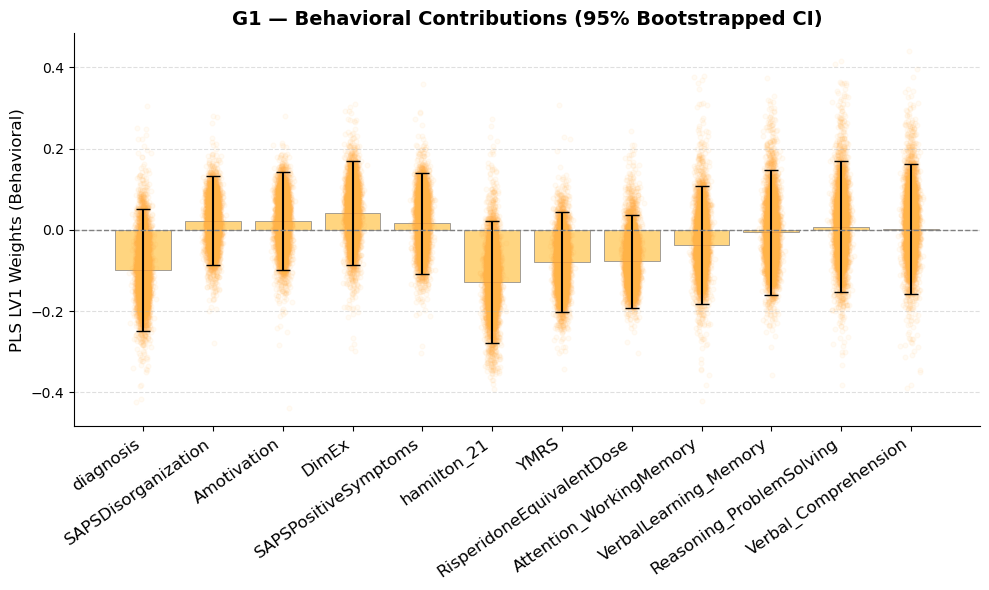


Bootstrap resampling for manifold G2...


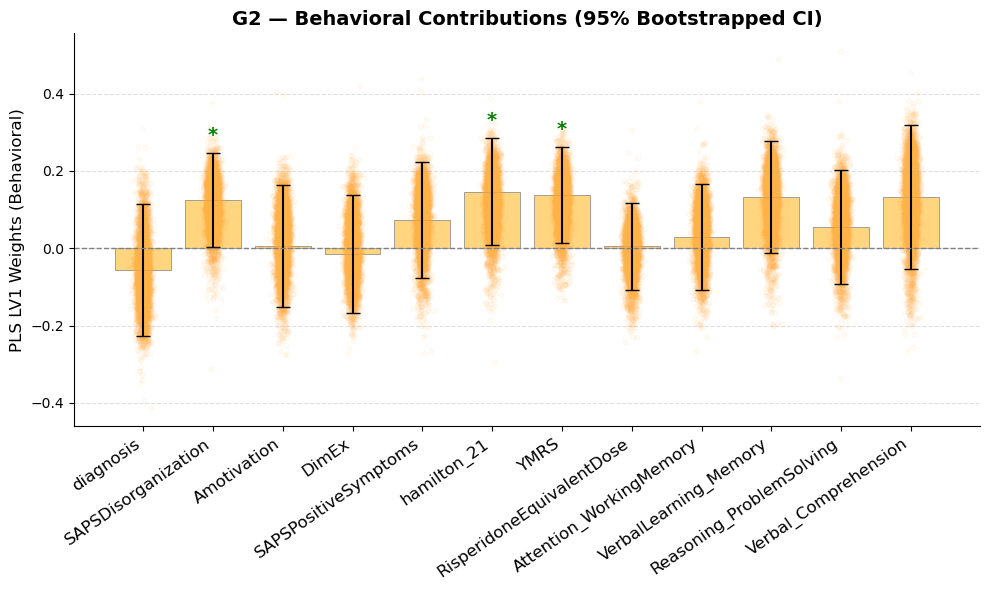


Bootstrap resampling for manifold G3...


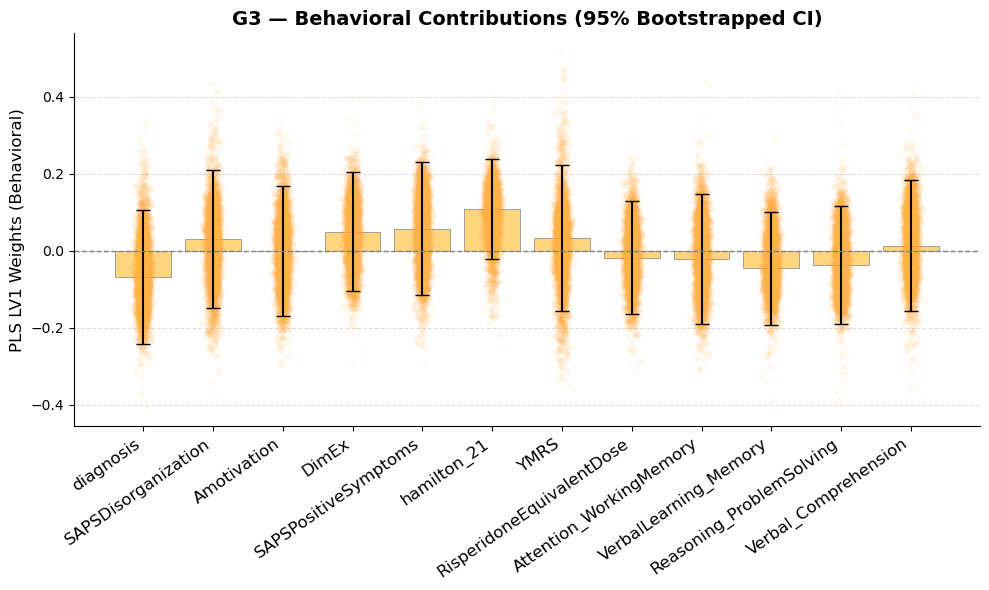

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.utils import resample

# -------------------------------
# Bootstrap parameters
# -------------------------------
n_bootstrap = 5000  # number of bootstrap resamples
n_components = 1     # LV1 only
results_boot_manifold = {}    # store bootstrap ratios

# Color palette for plotting
bar_color = '#FFD580'
point_color = '#FFB347'
star_color = 'green'  # significant bars highlighted with green stars

# -------------------------------
# Loop over gradients (manifold)
# -------------------------------
for grad_name, res in results_manifold.items():
    print(f"\nBootstrap resampling for manifold {grad_name}...")

    # Standardized X and Y
    X = res['X_std']
    Y = res['Y_std']

    # Remove subjects with NaNs
    valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
    X = X[valid_mask]
    Y = Y[valid_mask]
    n_subjects, n_voxels = X.shape
    n_behav = Y.shape[1]

    # Original PLS to get original weights
    pls_orig = PLSRegression(n_components=n_components)
    pls_orig.fit(X, Y)
    X_orig_weights = pls_orig.x_weights_[:, 0]
    Y_orig_weights = pls_orig.y_weights_[:, 0]

    # -----------------------
    # Bootstrap resampling
    # -----------------------
    X_boot_weights = np.zeros((n_bootstrap, n_voxels))
    Y_boot_weights = np.zeros((n_bootstrap, n_behav))

    for i in range(n_bootstrap):
        Xb, Yb = resample(X, Y, n_samples=n_subjects, replace=True)

        pls_boot = PLSRegression(n_components=n_components)
        pls_boot.fit(Xb, Yb)
        Xb_weights = pls_boot.x_weights_[:, 0]
        Yb_weights = pls_boot.y_weights_[:, 0]

        # Sign-flipping to align with original LV
        if np.dot(Xb_weights, X_orig_weights) < 0:
            Xb_weights *= -1
            Yb_weights *= -1

        X_boot_weights[i, :] = Xb_weights
        Y_boot_weights[i, :] = Yb_weights

    # -----------------------
    # Compute bootstrap ratios
    # -----------------------
    X_bsr = X_orig_weights / X_boot_weights.std(axis=0)
    Y_bsr = Y_orig_weights / Y_boot_weights.std(axis=0)

    results_boot_manifold[grad_name] = {
        'X_bsr': X_bsr,
        'Y_bsr': Y_bsr,
        'X_boot_weights': X_boot_weights,
        'Y_boot_weights': Y_boot_weights
    }

    # -----------------------
    # Behavioral bar plot visualization
    # -----------------------
    y_mean = Y_orig_weights
    y_sd = Y_boot_weights.std(axis=0)
    lower_ci = y_mean - 1.96 * y_sd
    upper_ci = y_mean + 1.96 * y_sd

    significant = (lower_ci > 0) | (upper_ci < 0)

    # Behavioral variable names
    Y_cols = list(res['behav_corrs'].keys())
    fig, ax = plt.subplots(figsize=(10,6))

    # Bars with error bars
    ax.bar(np.arange(n_behav), y_mean,
           width=0.8,
           yerr=[y_mean - lower_ci, upper_ci - y_mean],
           capsize=5, color=bar_color, edgecolor='gray', linewidth=0.5)

    # Overlay bootstrap points
    for j in range(n_behav):
        x = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(x, Y_boot_weights[:, j], color=point_color, alpha=0.05, s=12)

    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Significance stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                    fontsize=14, color=star_color, fontweight='bold')

    # Labels
    ax.set_xticks(np.arange(n_behav))
    ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('PLS LV1 Weights (Behavioral)', fontsize=12)
    ax.set_title(f'{grad_name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()


## Variance explained

Computing variance explained for manifold-based PLS across all gradients...

G1:
  LV1 explains 39.91% of X variance, 1.82% of Y variance, 60.72% of total X–Y cross-covariance energy, and t-u squared correlation = 19.60%

G2:
  LV1 explains 30.36% of X variance, 3.14% of Y variance, 74.82% of total X–Y cross-covariance energy, and t-u squared correlation = 15.98%

G3:
  LV1 explains 42.29% of X variance, 1.19% of Y variance, 50.21% of total X–Y cross-covariance energy, and t-u squared correlation = 9.72%



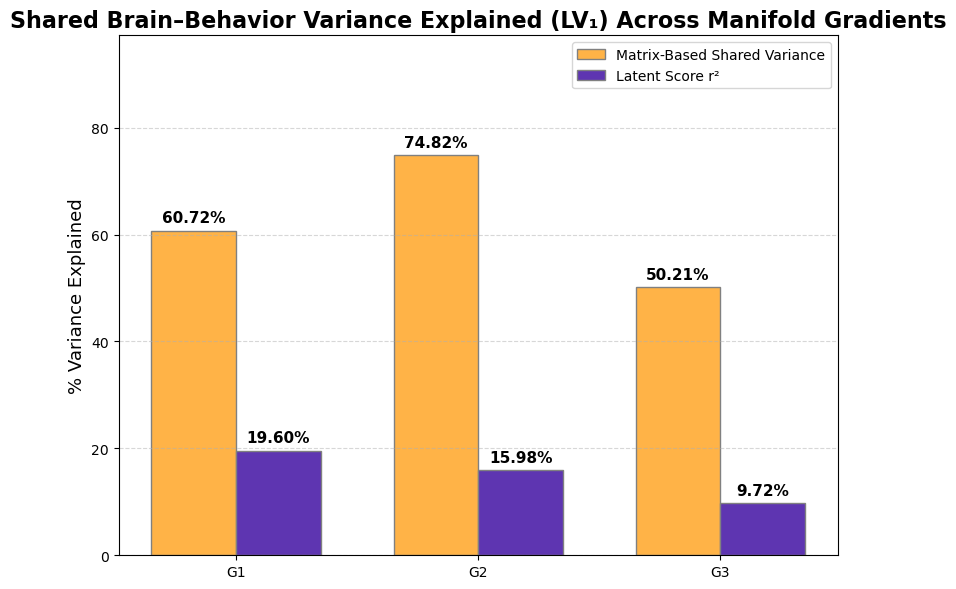

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
import os

os.makedirs("new_figures", exist_ok=True)

var_explained_manifold = {}

print("Computing variance explained for manifold-based PLS across all gradients...\n")

for grad_name, res in results_manifold.items():

    X = res['X_std']
    Y = res['Y_std']
    n_samples = X.shape[0]

    pls = PLSRegression(n_components=1)
    pls.fit(X, Y)

    # Predicted X and Y
    X_pred = pls.x_scores_ @ pls.x_loadings_.T
    Y_pred = pls.x_scores_ @ pls.y_loadings_.T

    # Variance explained
    var_X_expl = np.sum(X_pred**2) / np.sum(X**2)
    var_Y_expl = np.sum(Y_pred**2) / np.sum(Y**2)

    # Shared variance (matrix-based)
    C_full = (X.T @ Y) / (n_samples - 1)
    C_pred = (X_pred.T @ Y_pred) / (n_samples - 1)
    total_cross_energy = np.sum(C_full**2)
    explained_cross_energy = np.sum(C_pred**2)
    shared_var_matrix = 0.0 if total_cross_energy == 0 else explained_cross_energy / total_cross_energy

    # Latent score squared correlation
    t = pls.x_scores_[:, 0]
    u = pls.y_scores_[:, 0]
    r2_latent = np.corrcoef(t, u)[0, 1]**2

    # Store in results
    res['var_X_expl'] = var_X_expl
    res['var_Y_expl'] = var_Y_expl
    res['shared_var_matrix'] = shared_var_matrix
    res['r2_latent'] = r2_latent

    var_explained_manifold[grad_name] = {
        'X_var%': var_X_expl * 100,
        'Y_var%': var_Y_expl * 100,
        'Shared_matrix%': shared_var_matrix * 100,
        'r2_latent%': r2_latent * 100
    }

    print(f"{grad_name}:")
    print(f"  LV1 explains {var_X_expl*100:.2f}% of X variance, "
          f"{var_Y_expl*100:.2f}% of Y variance, "
          f"{shared_var_matrix*100:.2f}% of total X–Y cross-covariance energy, "
          f"and t-u squared correlation = {r2_latent*100:.2f}%\n")

# --- Combined plot for all gradients ---
grad_names = list(var_explained_manifold.keys())
matrix_vals = [v['Shared_matrix%'] for v in var_explained_manifold.values()]
latent_vals = [v['r2_latent%'] for v in var_explained_manifold.values()]

x = np.arange(len(grad_names))
width = 0.35  # width of the bars

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, matrix_vals, width, label='Matrix-Based Shared Variance', color='#FFB347', edgecolor='gray')
plt.bar(x + width/2, latent_vals, width, label='Latent Score r²', color='#5E35B1', edgecolor='gray')

# Add value labels
for i in range(len(grad_names)):
    plt.text(x[i] - width/2, matrix_vals[i] + 1, f"{matrix_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.text(x[i] + width/2, latent_vals[i] + 1, f"{latent_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(x, grad_names)
plt.ylabel("% Variance Explained", fontsize=13)
plt.title("Shared Brain–Behavior Variance Explained (LV₁) Across Manifold Gradients", fontsize=16, fontweight='bold')
plt.ylim(0, max(max(matrix_vals), max(latent_vals)) * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("new_figures/shared_variance_manifold_LV1.png", dpi=300)
plt.show()
